In [42]:
import matplotlib.pyplot as plt
import json
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

from common import *

In [43]:
test1 = json.load(open("./results/result_100000_4_1.json", "r"))

projection = np.matrix([
    [1,0,0],
    [0,1,0],
    [0,0,1]
])

In [44]:
points = {}
for p in test1["points"]:
    cluster = p["cluster"]
    if cluster not in points:
        points[cluster] = []
    points[cluster].append([p["x"], p["y"], p["z"]])
    
for cluster in points:
    points[cluster] = np.array(points[cluster])
sum = 0
for cluster in points:
    sum += len(points[cluster])
    print(f"[{cluster}] : {len(points[cluster])}")
print(f"=> {sum}")

[0] : 24996
[3] : 24996
[1] : 24997
[2] : 25011
=> 100000


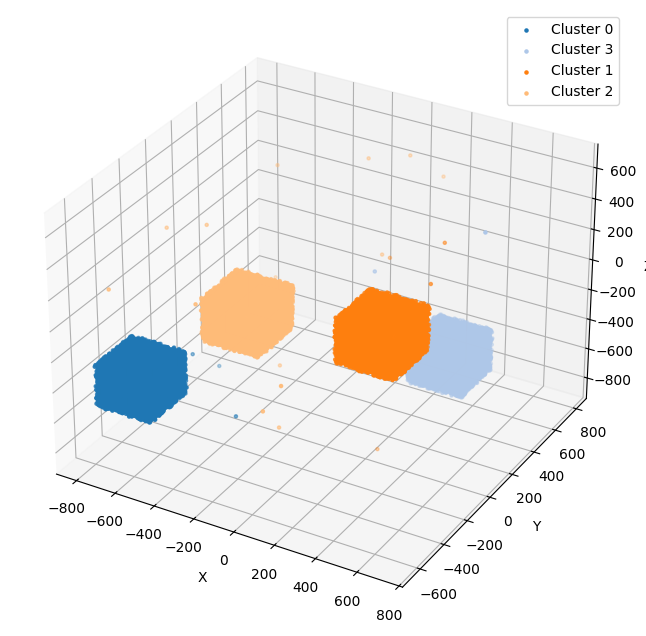

In [45]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

cmap = plt.get_cmap("tab20")

for i, (cluster, pts) in enumerate(points.items()):
    ax.scatter(
        pts[:, 0],
        pts[:, 1],
        pts[:, 2],
        color=cmap(i % 20),
        s=5,
        label=f"Cluster {cluster}"
    )

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

ax.legend()

plt.show()


In [46]:
data = json.load(open("./results.json", "r"))

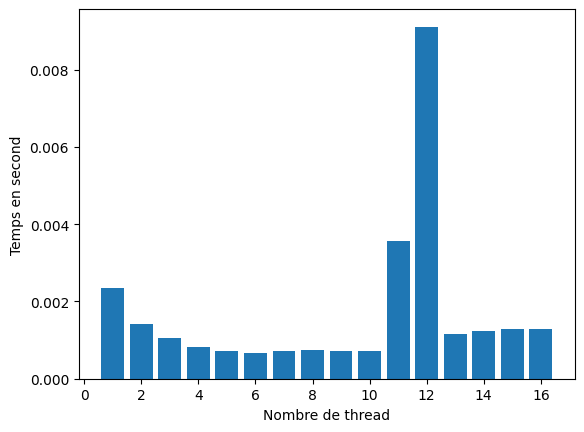

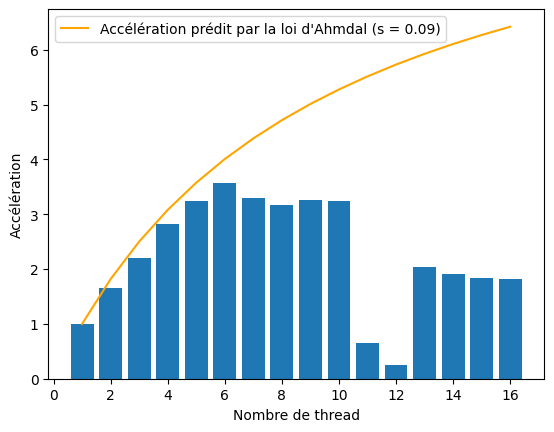

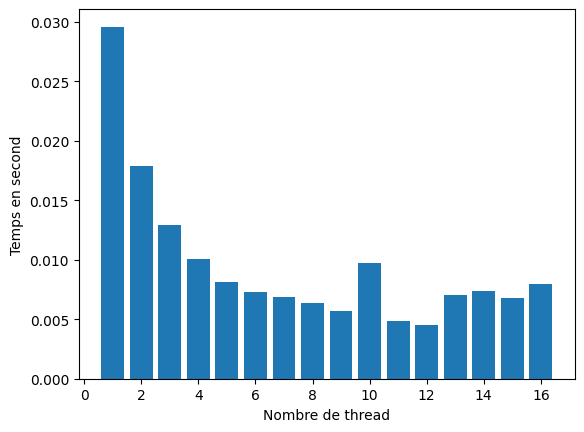

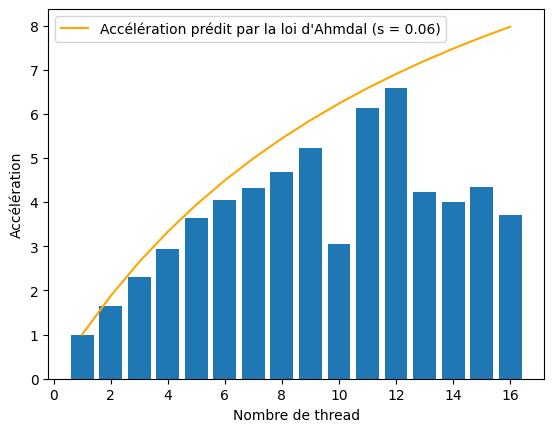

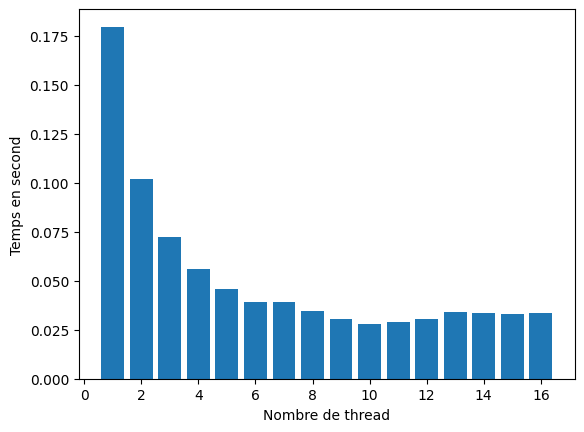

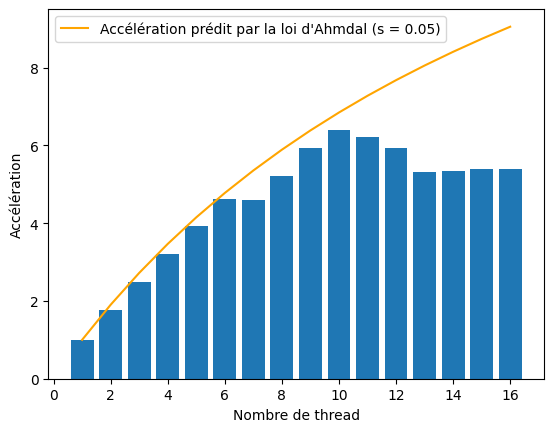

In [57]:
#dataset_10000_4
for (filename, size) in [("./test/datasets/dataset_10000_4.txt", 10000), ("./test/datasets/dataset_100000_4.txt", 100000), ("./test/datasets/dataset_1000000_4.txt", 1000000)]:
    times = []

    for nb_t in TEST_NBT:
        key = str((filename, 4, nb_t))
        times.append(data[key])

    acc = [times[0] / t for t in times]

    smax = max(acc)
    nmax = acc.index(smax)

    s = ((1/smax) - (1/nmax)) / (1 - 1/nmax)

    f = lambda n : 1/ (s + (1-s)/n)

    plt.bar(TEST_NBT, times)
    plt.xlabel("Nombre de thread")
    plt.ylabel("Temps en second")

    plt.savefig(f"./images/dataset_{size}_4_times.svg")
    plt.show()


    plt.bar(TEST_NBT, acc)
    plt.plot(TEST_NBT, f(np.array(TEST_NBT)), label=f"Accélération prédit par la loi d'Ahmdal (s = {int(s*100)/100})", color="orange")
    plt.legend()
    plt.xlabel("Nombre de thread")
    plt.ylabel("Accélération")

    plt.savefig(f"./images/dataset_{size}_4_acc.svg")

    plt.show()